In [2]:
# import et configurations
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta

# Affichage plus lisible
pd.set_option("display.max_columns", None)


In [3]:
# chargement des données
stock_df = pd.read_csv("stock.csv", parse_dates=["purchased_at"])
competitor_df = pd.read_csv("competitor_prices.csv", parse_dates=["timestamp"])
sales_df = pd.read_csv("sales_history.csv")


In [6]:
import math
from datetime import datetime

def suggest_price(sku, now, competitor_snapshot, unit_cost, shelf_life_hours, margin_floor=1.1):
    age_hours = (now - sku["purchased_at"]).total_seconds() / 3600
    freshness_factor = max(0, 1 - (age_hours / shelf_life_hours)**1.5)
    competitor_mean = sum(competitor_snapshot.values()) / len(competitor_snapshot) if competitor_snapshot else unit_cost * 1.3
    price = competitor_mean * freshness_factor
    min_price = unit_cost * margin_floor
    if price < min_price:
        price = min_price
    return round(price, 2)


In [7]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta

# Charger les CSV
stock_df = pd.read_csv("stock.csv", parse_dates=["purchased_at"])
competitor_df = pd.read_csv("competitor_prices.csv", parse_dates=["timestamp"])
sales_df = pd.read_csv("sales_history.csv")

# Simulation parameters
start_time = competitor_df["timestamp"].min()
end_time = start_time + timedelta(days=7)

results = []

for now in pd.date_range(start=start_time, end=end_time, freq="30min"):
    for _, sku_row in stock_df.iterrows():
        sku = {"purchased_at": sku_row["purchased_at"], "product": sku_row["product"]}
        unit_cost = sku_row["unit_cost_xaf"]
        shelf_life_hours = sku_row["shelf_life_hours"]

        # Snapshot concurrents
        snapshot = competitor_df[
            (competitor_df["timestamp"] == now) & (competitor_df["product"] == sku["product"])
        ]
        competitor_snapshot = dict(zip(snapshot["stall"], snapshot["price_xaf"]))

        # Trois stratégies
        dynamic_price = suggest_price(sku, now.to_pydatetime(), competitor_snapshot, unit_cost, shelf_life_hours)
        baseline_price = unit_cost * 1.3
        cheapest_price = snapshot["price_xaf"].min() if not snapshot.empty else baseline_price

        # Quantité vendue estimée (via sales_history)
        demand_curve = sales_df[
            (sales_df["product"] == sku["product"]) & (sales_df["price_xaf"] == round(dynamic_price, 2))
        ]
        quantity_sold = demand_curve["quantity_sold"].mean() if not demand_curve.empty else 0

        results.append({
            "timestamp": now,
            "product": sku["product"],
            "dynamic_price": dynamic_price,
            "baseline_price": baseline_price,
            "cheapest_price": cheapest_price,
            "quantity_sold": quantity_sold,
            "unit_cost": unit_cost
        })

results_df = pd.DataFrame(results)


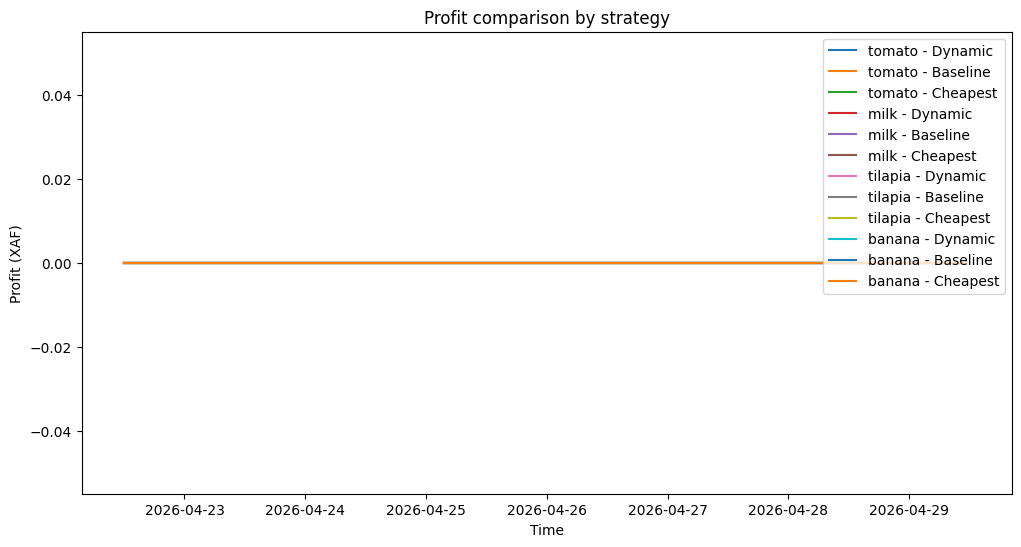

In [8]:
results_df["profit_dynamic"] = (results_df["dynamic_price"] - results_df["unit_cost"]) * results_df["quantity_sold"]
results_df["profit_baseline"] = (results_df["baseline_price"] - results_df["unit_cost"]) * results_df["quantity_sold"]
results_df["profit_cheapest"] = (results_df["cheapest_price"] - results_df["unit_cost"]) * results_df["quantity_sold"]

plt.figure(figsize=(12,6))
for product in results_df["product"].unique():
    subset = results_df[results_df["product"] == product]
    plt.plot(subset["timestamp"], subset["profit_dynamic"], label=f"{product} - Dynamic")
    plt.plot(subset["timestamp"], subset["profit_baseline"], label=f"{product} - Baseline")
    plt.plot(subset["timestamp"], subset["profit_cheapest"], label=f"{product} - Cheapest")
plt.legend()
plt.title("Profit comparison by strategy")
plt.xlabel("Time")
plt.ylabel("Profit (XAF)")
plt.show()


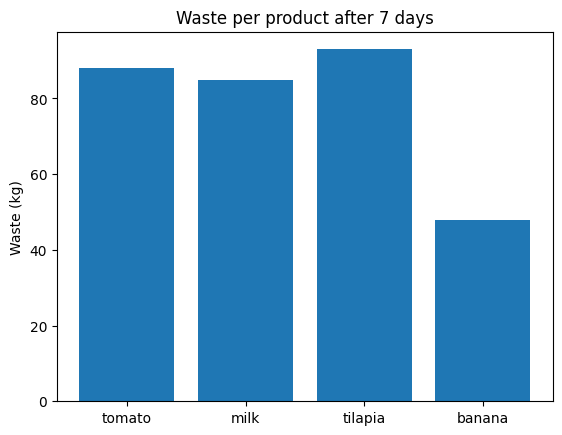

In [10]:
# Exemple simple : quantité initiale - quantité vendue cumulée
waste_df = results_df.groupby("product")["quantity_sold"].sum().reset_index()
stock_init = stock_df[["product","quantity"]]
waste_df = stock_init.merge(waste_df, on="product")
waste_df["waste_kg"] = waste_df["quantity"] - waste_df["quantity_sold"]

plt.bar(waste_df["product"], waste_df["waste_kg"])
plt.title("Waste per product after 7 days")
plt.ylabel("Waste (kg)")
plt.show()


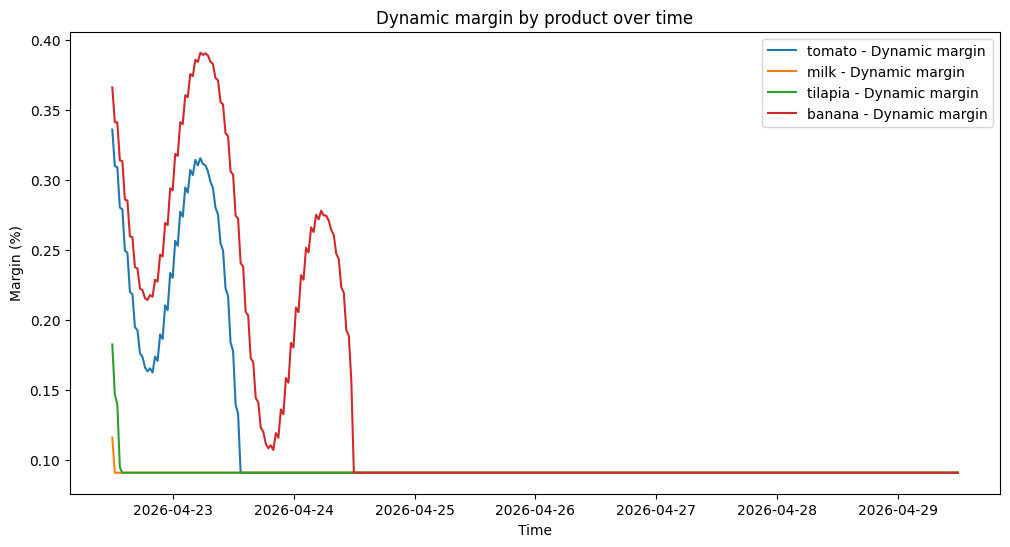

In [11]:
results_df["margin_dynamic"] = (results_df["dynamic_price"] - results_df["unit_cost"]) / results_df["dynamic_price"]

plt.figure(figsize=(12,6))
for product in results_df["product"].unique():
    subset = results_df[results_df["product"] == product]
    plt.plot(subset["timestamp"], subset["margin_dynamic"], label=f"{product} - Dynamic margin")
plt.legend()
plt.title("Dynamic margin by product over time")
plt.xlabel("Time")
plt.ylabel("Margin (%)")
plt.show()
